# Glioma — Fig. 5 E–H
E is recalculated from PTEN expression normalized to 10,000 counts per measured panel.
F/G fit the full healthy/GBM pair (S0) and two fixed local GBM domains (S1/S2), each for 100 epochs. The complete healthy reference is retained in all three cases. PTEN is multiplied by five only within the inner radius-400 ROI, followed by frozen inference.
H reads the completed 319-gene KO/OE and regulon screen.
S1 is the original GT8 geometry; S2 is BF16. The ROI search is not repeated.

In [1]:
from pathlib import Path
import sys, os
ROOT = Path("/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main")
TUTORIAL = ROOT / "tutorial"
FRAMEWORK = TUTORIAL / "_framework/BrainBeacon"
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(FRAMEWORK))
from brainbeacon.configs.config import DEFAULT_PATHS
DEFAULT_PATHS.update({
    "BASE_DIR": str(ROOT), "PRIOR_DIR": str(ROOT / "prior_knowledge"),
    "PRETRAIN_DIR": str(ROOT / "pretrained"),
    "GENE_DICT_PATH": str(ROOT / "prior_knowledge/gene_dict.h5ad"),
    "GENE_LOOKUP_DIR": str(ROOT / "prior_knowledge/gene_lookup"),
    "ESM_EMBED_PATH": str(ROOT / "prior_knowledge/esm2_embeddings_d5120.pt"),
})

In [2]:
import gc, json, logging, warnings
import anndata as ad
import scanpy as sc
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from scipy import sparse
from scipy.stats import spearmanr
from IPython.display import display
from brainbeacon.pipeline.cell_embedding import run_brainbeacon_pipeline
from brainbeacon.pipeline.perturbation import apply_gene_perturbation
from brainbeacon.tokenizer import set_seed
set_seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
BRAINBEACON_ROOT = ROOT
analysis_dir = TUTORIAL / "outputs/fig5_glioma"
analysis_dir.mkdir(parents=True, exist_ok=True)
FIG_DIR = TUTORIAL / "figures/fig5_glioma"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"pdf.fonttype":42, "ps.fonttype":42, "svg.fonttype":"none", "font.size":10})
def save_panel(fig, stem):
    for extension in ("pdf", "svg", "png"):
        fig.savefig(FIG_DIR / f"{stem}.{extension}", dpi=300, bbox_inches="tight")
    plt.show()

/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/7936-yangyiwen/conda/miniconda/envs/bb_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
dataset_name = 'xenium_human_preview_ffpe_healthy_vs_gbm_circle_target_gene'
species = 'human'
assay = 'xenium'
BASE_DIR = Path(BRAINBEACON_ROOT)
GLIOMA_DATA_DIR = Path('/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/GliomaProj/Glioma-data/01_raw/GBM_data/Xenium_health/Xenium/Xenium_Human_Preview_FFPE')
healthy_adata_path = GLIOMA_DATA_DIR / 'Xenium_V1_FFPE_Human_Brain_Healthy_With_Addon.h5ad'
gbm_adata_path = GLIOMA_DATA_DIR / 'Xenium_V1_FFPE_Human_Brain_Glioblastoma_With_Addon.h5ad'
gene_dict_path = BASE_DIR / 'prior_knowledge' / 'gene_dict.h5ad'
stage1_ckpt_path = BASE_DIR / 'prior_knowledge' / 'ABL1_full_final_epoch_0_step_10000.pt'
stage2_ckpt_path = BASE_DIR / 'prior_knowledge' / 'ckpt_0512_epoch600continue' / 'ABL1_fix_ckpts_new' / 'ep280_ckpt' / 'stage2_epoch_200.pt'
stage1_config = {'dim_model': 1024, 'dim_feedforward': 1024, 'nheads': 16, 'nlayers': 16, 'n_connect_comp': 46714, 'use_esm_emb': True, 'use_gene_id_emb': True, 'use_homo_emb': True, 'use_rna_type_emb': True, 'use_gene_deviation': True, 'use_cell_density': True, 'use_dev_abs': True, 'esm_emb_dim': 5120, 'species': True, 'assay': True, 'n_hvg': 5000, 'cd_weight': 0.02, 'use_hvg': True, 'weight_mode': 'expression', 'force_tokenize': True}
stage2_config = {'sampling_mode': 'spatial', 'use_patch': False, 'eval_use_patch': False, 'max_eval_batch_size': 50000}
n_hvg = stage1_config['n_hvg']
cd_weight = stage1_config['cd_weight']
use_hvg = stage1_config['use_hvg']
stage1_tag = stage1_ckpt_path.stem
stage2_tag = stage2_ckpt_path.stem
if use_hvg:
    method_name = f'bb_{stage1_tag}_s2_{stage2_tag}_hvg{n_hvg}_cd{cd_weight}'
else:
    method_name = f'bb_{stage1_tag}_s2_{stage2_tag}_cd{cd_weight}'
output_dir = analysis_dir / method_name
output_dir.mkdir(parents=True, exist_ok=True)
gene_dict = sc.read_h5ad(gene_dict_path)
gene_meta = gene_dict.var.copy()
if 'species' in gene_meta.columns:
    gene_meta = gene_meta.loc[gene_meta['species'].astype(str).str.lower().eq(species)].copy()
gene_meta['gene_symbol'] = gene_meta['gene_symbol'].astype(str)
ens_to_symbol = dict(zip(gene_meta.index.astype(str), gene_meta['gene_symbol']))
healthy = sc.read_h5ad(healthy_adata_path)
gbm = sc.read_h5ad(gbm_adata_path)
healthy.var_names = healthy.var_names.astype(str)
gbm.var_names = gbm.var_names.astype(str)
gbm_genes = set(gbm.var_names)
dict_genes = set(gene_dict.var_names.astype(str))
shared_genes = [g for g in healthy.var_names if g in gbm_genes and g in dict_genes]
healthy = healthy[:, shared_genes].copy()
gbm = gbm[:, shared_genes].copy()
HEALTHY_SLICE = 'Xenium_V1_FFPE_Human_Brain_Healthy_With_Addon'
GBM_SLICE = 'Xenium_V1_FFPE_Human_Brain_Glioblastoma_With_Addon'
healthy.obs_names = [f'healthy:{x}' for x in healthy.obs_names.astype(str)]
gbm.obs_names = [f'GBM:{x}' for x in gbm.obs_names.astype(str)]
for (part, condition_name, slice_name, label) in [(healthy, 'healthy', HEALTHY_SLICE, 'Healthy'), (gbm, 'GBM', GBM_SLICE, 'GBM')]:
    part.obs['condition'] = condition_name
    part.obs['disease_state'] = condition_name
    part.obs['slice'] = slice_name
    part.obs['cell_label'] = label
    part.obs['species'] = species
    part.obs['platform'] = assay
    part.obs['batch'] = slice_name
adata = ad.concat([healthy, gbm], join='inner', index_unique=None)
adata.var = gene_dict.var.loc[adata.var_names].copy()
adata.var['gene_symbol'] = [ens_to_symbol.get(g, str(g)) for g in adata.var_names]
adata.obs['region'] = 'preview_human_ffpe'
adata.obs['brain_region'] = 'xenium_human_preview_ffpe'
adata.obs['dataset'] = 'xenium_gbm'
shape_before_qc = adata.shape
sc.pp.filter_cells(adata, min_genes=3)
sc.pp.filter_genes(adata, min_cells=3)
adata.var = gene_dict.var.loc[adata.var_names].copy()
adata.var['gene_symbol'] = [ens_to_symbol.get(g, str(g)) for g in adata.var_names]
print(f'[QC] {shape_before_qc} -> {adata.shape}')
print(adata.obs['condition'].astype(str).value_counts())
print('Complete pair retained; no ROI cropping:', adata)

[QC] (65293, 319) -> (65268, 319)
condition
GBM        40874
healthy    24394
Name: count, dtype: int64
Complete pair retained; no ROI cropping: AnnData object with n_obs × n_vars = 65268 × 319
    obs: 'bin_count', 'slice', 'species', 'cell_label', 'condition', 'disease_state', 'platform', 'batch', 'region', 'brain_region', 'dataset', 'n_genes'
    var: 'gene_id', 'gene_symbol', 'species', 'homo_connect_id_old', 'homo_connect_id', 'gene_type', 'gene_type_id', 'esm_norm', 'has_esm', 'mean_merfish', 'mean_slideseqv2', 'mean_starmap', 'mean_stereo', 'mean_xenium', 'homo_esm_rnatype_group_size', 'not_unique_homo_esm_rnatype'
    obsm: 'spatial'


In [4]:
stage1_config.update(hvg_log1p=True, use_mean_norm=True)
stage2_config["pe_weight"] = 1.0
TARGET_GENE = adata.var_names[adata.var["gene_symbol"].eq("PTEN")][0]
ROI_RADIUS = 400.0
cases = [
    dict(display_id="S0",x=2500.,y=2000.,domain_radius=None),
    dict(display_id="GT8",x=1800.,y=3000.,domain_radius=1600.),
    dict(display_id="BF16",x=5900.,y=1700.,domain_radius=1200.),
]

## E. Measured PTEN expression

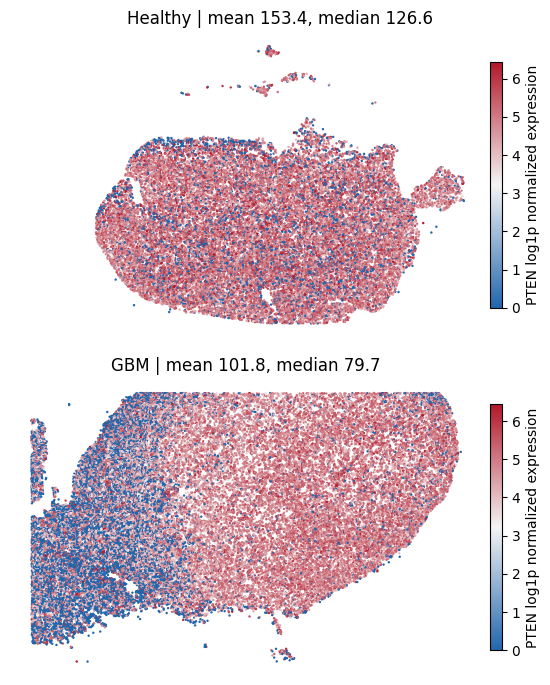

In [4]:
gene_idx = adata.var_names.get_loc(TARGET_GENE)
raw = adata.X[:,gene_idx]
raw = raw.toarray().ravel() if sparse.issparse(raw) else np.asarray(raw).ravel()
totals = np.asarray(adata.X.sum(axis=1)).ravel()
normalized = raw / np.maximum(totals,1) * 10000.
expression = np.log1p(normalized)
vmax = np.quantile(expression[expression>0],.99)
cmap = LinearSegmentedColormap.from_list("PTEN_expression",["#2166AC","#F4F4F4","#B2182B"])
fig, axes = plt.subplots(2,1,figsize=(5.6,7.0))
expression_summary = []
for ax, condition in zip(axes,["healthy","GBM"]):
    mask = adata.obs["condition"].eq(condition).to_numpy()
    xy = np.asarray(adata.obsm["spatial"])[mask]
    points = ax.scatter(xy[:,0],xy[:,1],c=expression[mask],cmap=cmap,vmin=0,vmax=vmax,s=3,linewidths=0,rasterized=True)
    mean,median = normalized[mask].mean(),np.median(normalized[mask])
    ax.set_title(f"{('Healthy' if condition == 'healthy' else 'GBM')} | mean {mean:.1f}, median {median:.1f}")
    ax.set_aspect("equal");ax.invert_yaxis();ax.axis("off")
    fig.colorbar(points,ax=ax,fraction=.025,pad=.015,label="PTEN log1p normalized expression")
    expression_summary.append(dict(condition=condition,mean=mean,median=median,n_cells=int(mask.sum())))
pd.DataFrame(expression_summary).to_csv(analysis_dir / "Fig5_E_PTEN_expression.csv",index=False)
fig.tight_layout()
save_panel(fig,"Fig5_E_PTEN_expression")

## F/G. Fit and perturb the three fixed ROI cases

In [6]:
def cosine_to_centroid(embedding, centroid):
    embedding = np.nan_to_num(np.asarray(embedding, dtype=float))
    return embedding @ centroid / (np.linalg.norm(embedding, axis=1) * np.linalg.norm(centroid) + 1e-12)

def fit_roi_case(case):
    label, center = case["display_id"], np.array([case["x"],case["y"]])
    xy_all = np.asarray(adata.obsm["spatial"], dtype=float)
    distance_all = np.linalg.norm(xy_all-center, axis=1)
    healthy_mask = adata.obs["condition"].eq("healthy").to_numpy()
    domain = adata.obs["condition"].eq("GBM").to_numpy()
    if case["domain_radius"] is not None:
        domain &= distance_all <= case["domain_radius"]
    subset = adata[healthy_mask | domain].copy()
    subset.obs["split"] = "train"
    xy = np.asarray(subset.obsm["spatial"], dtype=float)
    is_gbm = subset.obs["condition"].eq("GBM").to_numpy()
    roi = is_gbm & (np.linalg.norm(xy-center, axis=1) <= ROI_RADIUS)
    subset.obs["roi_label"] = "GBM_outside_ROI"
    subset.obs.loc[~is_gbm, "roi_label"] = "Healthy_reference"
    subset.obs.loc[roi, "roi_label"] = "PTEN_OE5X_ROI"
    subset.obs["cell_type"] = pd.Categorical(subset.obs["roi_label"], categories=["Healthy_reference","GBM_outside_ROI","PTEN_OE5X_ROI"])
    case_dir = analysis_dir / label
    case_dir.mkdir(exist_ok=True)
    checkpoint = case_dir / "baseline_cellformer.pt"
    subset.write_h5ad(case_dir / "unmodified_input.h5ad")
    print(label, "input", subset.shape, "ROI cells", int(roi.sum()))
    baseline = run_brainbeacon_pipeline(
        adata=subset, species=species, assay=assay, gene_dict_path=str(gene_dict_path),
        stage1_ckpt_path=str(stage1_ckpt_path), stage2_ckpt_path=str(stage2_ckpt_path),
        output_dir=str(case_dir), output_prefix="baseline", stage1_config=dict(stage1_config),
        stage2_config=dict(stage2_config), do_fit=True, fit_epochs=100, save_model=True,
        save_model_path=str(checkpoint), device=device, seed=42, deterministic=True)
    baseline.write_h5ad(case_dir / "baseline_result.h5ad")
    modified, changed = apply_gene_perturbation(
        adata=subset, gene_list=[TARGET_GENE], mode="overexpress", target_obs_names=subset.obs_names[roi],
        multiplier=5., value=None, perturb_percent=100, random_state=0)
    modified.write_h5ad(case_dir / "PTEN_OE5x_input.h5ad")
    virtual = run_brainbeacon_pipeline(
        adata=modified, species=species, assay=assay, gene_dict_path=str(gene_dict_path),
        stage1_ckpt_path=str(stage1_ckpt_path), stage2_ckpt_path=str(checkpoint),
        output_dir=str(case_dir), output_prefix="PTEN_OE5x", stage1_config=dict(stage1_config),
        stage2_config=dict(stage2_config), do_fit=False, fit_epochs=0, save_model=False,
        device=device, seed=42, deterministic=True)
    virtual.write_h5ad(case_dir / "PTEN_OE5x_result.h5ad")
    before = np.asarray(baseline.obsm["X_emb"], dtype=float)
    after = np.asarray(virtual[baseline.obs_names].obsm["X_emb"], dtype=float)
    reference = before[~is_gbm].mean(axis=0)
    delta = cosine_to_centroid(after[is_gbm], reference)-cosine_to_centroid(before[is_gbm], reference)
    xy_gbm = xy[is_gbm]
    distance = np.linalg.norm(xy_gbm-center, axis=1)
    table = pd.DataFrame(dict(cell=subset.obs_names[is_gbm], x=xy_gbm[:,0], y=xy_gbm[:,1],
                              delta_cosine=delta, is_roi=distance<=ROI_RADIUS,
                              distance=np.maximum(distance-ROI_RADIUS,0)))
    table.to_csv(case_dir / "cell_response.csv", index=False)
    del baseline, virtual, modified, subset
    gc.collect(); torch.cuda.empty_cache()
    return table

def distance_profile(table, case):
    outside = ~table["is_roi"].to_numpy()
    distance = table["distance"].to_numpy()
    if case["domain_radius"] is None:
        far = outside & (distance>=3000)
        width, limit, min_cells = 250., 4000., 1
    else:
        limit = case["domain_radius"]-ROI_RADIUS
        far = outside & (distance>=limit-300) & (distance<=limit)
        width, min_cells = 100., 30
    centered = table["delta_cosine"]-np.median(table.loc[far,"delta_cosine"])
    values = pd.DataFrame(dict(distance=distance[outside], raw_delta=table.loc[outside,"delta_cosine"].to_numpy(), local=centered[outside].to_numpy()))
    edges = np.arange(0, limit+width, width)
    if case["domain_radius"] is not None and edges[-1]<=limit:
        edges=np.append(edges,limit+1e-9)
    values["bin"] = pd.cut(values["distance"], edges, right=False, include_lowest=True)
    profile = values.groupby("bin", observed=True).agg(
        distance_median=("distance","median"), raw_median=("raw_delta","median"),
        raw_q25=("raw_delta",lambda x:np.percentile(x,25)),raw_q75=("raw_delta",lambda x:np.percentile(x,75)),
        local_median=("local","median"), local_q25=("local",lambda x:np.percentile(x,25)),
        local_q75=("local",lambda x:np.percentile(x,75)),n_cells=("local","size")).reset_index()
    return profile[profile.n_cells>=min_cells].copy()

### S0

In [7]:
case = cases[0]
response_s0 = fit_roi_case(case)
profile_s0 = distance_profile(response_s0, case)
profile_s0.to_csv(analysis_dir / case["display_id"] / "distance_summary.csv", index=False)
display(profile_s0)

S0 input (65268, 319) ROI cells 870
====== Stage1: Inference (memory) ======
[Stage1 memory] Tokenizing in memory...


Computing cell density...
compute_density_token time: 0.0924 seconds


[Stage1 memory] Tokenization done: 65268 cells, 14.4s


[Stage1 memory] Running inference (batch_size=64)...


/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/_framework/BrainBeacon/brainbeacon/pipeline/cell_embedding.py:372: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues

...

[INFO] Loading stage2 pretrained checkpoint: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_glioma/S0/baseline_cellformer.pt
[INFO] Skipped parameters (0): []


/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/_framework/BrainBeacon/brainbeacon/bbcellformer/pipeline/__init__.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any 

After filtering, 319 genes remain.


Embeddings saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_glioma/S0/PTEN_OE5x_stage2_embeddings.npz


,bin,distance_median,raw_median,raw_q25,raw_q75,local_median,local_q25,local_q75,n_cells
0,"[0.0, 250.0)",142.264137,0.003761,0.002414,0.004953,0.001561,0.000213,0.002753,1233
1,"[250.0, 500.0)",384.995775,0.003834,0.002797,0.004920,0.001634,0.000597,0.002719,1925
2,"[500.0, 750.0)",637.013619,0.003821,0.002655,0.004781,0.001620,0.000455,0.002580,2620
3,"[750.0, 1000.0)",881.252084,0.003755,0.002709,0.004762,0.001554,0.000508,0.002562,3529
4,"[1000.0, 1250.0)",1128.452958,0.003757,0.002689,0.004693,0.001556,0.000488,0.002493,4412
5,"[1250.0, 1500.0)",1369.253093,0.003639,0.002660,0.004525,0.001438,0.000460,0.002325,3890
6,"[1500.0, 1750.0)",1614.564254,0.003413,0.002389,0.004272,0.001213,0.000189,0.002071,3322
7,"[1750.0, 2000.0)",1878.610023,0.003275,0.002130,0.004255,0.001075,-0.000070,0.002054,2598
8,"[2000.0, 2250.0)",2114.393413,0.003196,0.002091,0.004214,0.000996,-0.000110,0.002013,3000
9,"[2250.0, 2500.0)",2367.754902,0.002950,0.001690,0.004083,0.000750,-0.000510,0.001883,2131


### S1

In [8]:
case = cases[1]
response_s1 = fit_roi_case(case)
profile_s1 = distance_profile(response_s1, case)
profile_s1.to_csv(analysis_dir / case["display_id"] / "distance_summary.csv", index=False)
display(profile_s1)

GT8 input (37920, 319) ROI cells 935
====== Stage1: Inference (memory) ======
[Stage1 memory] Tokenizing in memory...


Computing cell density...
compute_density_token time: 0.0508 seconds


[Stage1 memory] Tokenization done: 37920 cells, 4.0s


[Stage1 memory] Running inference (batch_size=64)...


/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/_framework/BrainBeacon/brainbeacon/pipeline/cell_embedding.py:372: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues

...

[INFO] Loading stage2 pretrained checkpoint: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_glioma/GT8/baseline_cellformer.pt
[INFO] Skipped parameters (0): []


/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/_framework/BrainBeacon/brainbeacon/bbcellformer/pipeline/__init__.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any 

After filtering, 319 genes remain.


Embeddings saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_glioma/GT8/PTEN_OE5x_stage2_embeddings.npz


,bin,distance_median,raw_median,raw_q25,raw_q75,local_median,local_q25,local_q75,n_cells
0,"[0.0, 100.0)",52.451319,0.012397,0.009344,0.016406,0.000938,-0.002115,0.004946,515
1,"[100.0, 200.0)",154.951165,0.013467,0.010904,0.016167,0.002007,-0.000556,0.004708,593
2,"[200.0, 300.0)",247.865599,0.013232,0.010869,0.015957,0.001772,-0.000591,0.004498,694
3,"[300.0, 400.0)",353.253856,0.012587,0.010189,0.015427,0.001128,-0.001271,0.003967,927
4,"[400.0, 500.0)",452.153197,0.013055,0.010409,0.015806,0.001595,-0.001051,0.004347,1034
5,"[500.0, 600.0)",551.122681,0.012374,0.009999,0.015022,0.000914,-0.001460,0.003563,1124
6,"[600.0, 700.0)",649.668762,0.012214,0.009870,0.015018,0.000755,-0.001589,0.003558,1193
7,"[700.0, 800.0)",749.957507,0.012374,0.009750,0.014865,0.000914,-0.001710,0.003406,1215
8,"[800.0, 900.0)",847.484219,0.011597,0.009000,0.014364,0.000137,-0.002459,0.002904,1322
9,"[900.0, 1000.0)",951.197846,0.011511,0.008996,0.014339,0.000051,-0.002463,0.002879,1383


### S2

In [9]:
case = cases[2]
response_s2 = fit_roi_case(case)
profile_s2 = distance_profile(response_s2, case)
profile_s2.to_csv(analysis_dir / case["display_id"] / "distance_summary.csv", index=False)
display(profile_s2)

BF16 input (29156, 319) ROI cells 499
====== Stage1: Inference (memory) ======
[Stage1 memory] Tokenizing in memory...
Computing cell density...


compute_density_token time: 0.0386 seconds


[Stage1 memory] Tokenization done: 29156 cells, 3.2s


[Stage1 memory] Running inference (batch_size=64)...


/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/_framework/BrainBeacon/brainbeacon/pipeline/cell_embedding.py:372: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues

...

[INFO] Loading stage2 pretrained checkpoint: /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_glioma/BF16/baseline_cellformer.pt


/inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/_framework/BrainBeacon/brainbeacon/bbcellformer/pipeline/__init__.py:86: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any 

[INFO] Skipped parameters (0): []
After filtering, 319 genes remain.


Embeddings saved to /inspire/ssd/project/sais-lifescience/public/workspace/yangyiwen/BrainProj/BrainBeacon-main/tutorial/outputs/fig5_glioma/BF16/PTEN_OE5x_stage2_embeddings.npz


,bin,distance_median,raw_median,raw_q25,raw_q75,local_median,local_q25,local_q75,n_cells
0,"[0.0, 100.0)",53.598275,0.012203,0.008843,0.015575,0.001895,-0.001465,0.005266,278
1,"[100.0, 200.0)",154.281576,0.011788,0.008729,0.015454,0.001480,-0.001579,0.005146,339
2,"[200.0, 300.0)",252.903300,0.012406,0.009355,0.015617,0.002098,-0.000954,0.005308,380
3,"[300.0, 400.0)",354.024617,0.011166,0.008179,0.014348,0.000858,-0.002130,0.004040,461
4,"[400.0, 500.0)",448.856393,0.011548,0.008505,0.014842,0.001240,-0.001803,0.004534,576
5,"[500.0, 600.0)",551.967501,0.010758,0.007314,0.013755,0.000450,-0.002994,0.003447,684
6,"[600.0, 700.0)",651.210580,0.010739,0.007351,0.013944,0.000431,-0.002957,0.003636,745
7,"[700.0, 800.0)",748.754689,0.009540,0.006794,0.013059,-0.000768,-0.003514,0.002751,800


### F. Full-slice spatial response

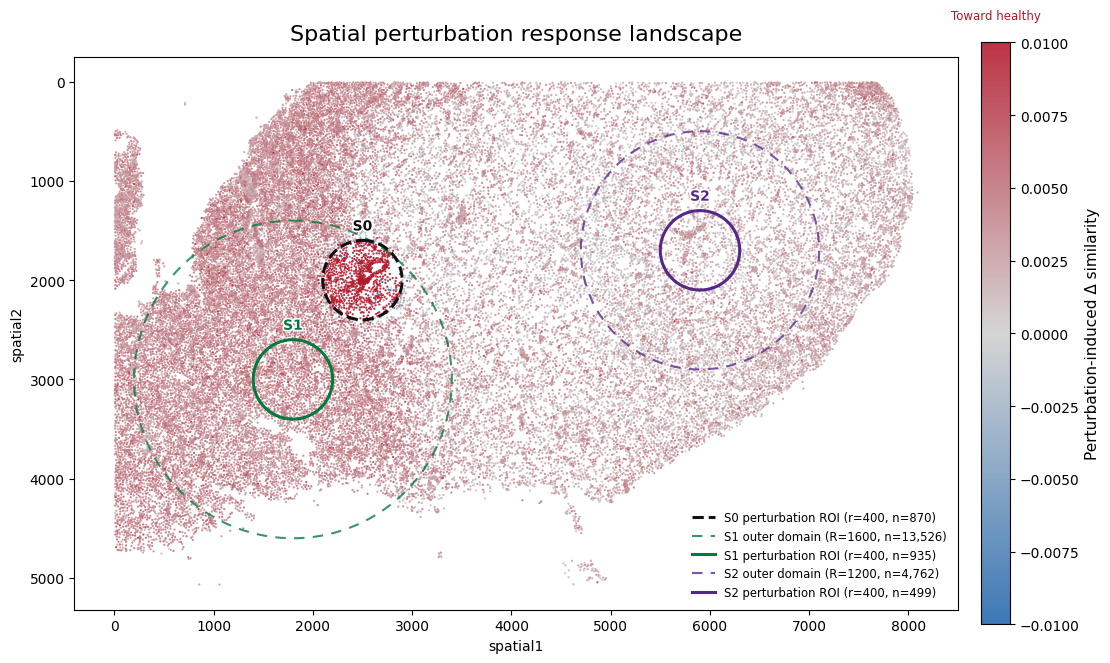

Complete GBM cells: 40874
Δ-similarity range: -0.06815947959772146 0.34939030777835595
Figure labels: S1 = GT8; S2 = BF16


In [10]:
import matplotlib.patheffects as pe
xy = response_s0[['x', 'y']].to_numpy()
delta_similarity = response_s0['delta_cosine'].to_numpy()
delta_cmap = LinearSegmentedColormap.from_list('blue_gray_red', ['#2166AC', '#D0D0D0', '#B2182B'])
delta_norm = TwoSlopeNorm(vmin=-0.01, vcenter=0.0, vmax=0.01)
roi_specs = [{'label': 'S0', 'source': 'complete-slice ROI', 'x': 2500.0, 'y': 2000.0, 'r': 400.0, 'outer_r': None, 'color': '#111111', 'ls': '--'}, {'label': 'S1', 'source': 'left local example', 'x': 1800.0, 'y': 3000.0, 'r': 400.0, 'outer_r': 1600.0, 'color': '#007A3D', 'ls': '-'}, {'label': 'S2', 'source': 'right local example', 'x': 5900.0, 'y': 1700.0, 'r': 400.0, 'outer_r': 1200.0, 'color': '#542788', 'ls': '-'}]
(fig, ax) = plt.subplots(figsize=(11.2, 6.8))
points = ax.scatter(xy[:, 0], xy[:, 1], c=delta_similarity, cmap=delta_cmap, norm=delta_norm, s=2.6, alpha=0.88, linewidths=0, rasterized=True, zorder=2)
legend_handles = []
for spec in roi_specs:
    distance = np.hypot(xy[:, 0] - spec['x'], xy[:, 1] - spec['y'])
    n_cells = int(np.sum(distance <= spec['r']))
    if spec['outer_r'] is not None:
        n_domain_cells = int(np.sum(distance <= spec['outer_r']))
        outer_circle = Circle((spec['x'], spec['y']), spec['outer_r'], fill=False, edgecolor=spec['color'], linewidth=1.5, linestyle=(0, (5, 4)), alpha=0.78, zorder=8)
        ax.add_patch(outer_circle)
        legend_handles.append(Line2D([0], [0], color=spec['color'], lw=1.5, linestyle=(0, (5, 4)), alpha=0.78, label=f"{spec['label']} outer domain (R={spec['outer_r']:.0f}, n={n_domain_cells:,})"))
    inner_circle = Circle((spec['x'], spec['y']), spec['r'], fill=False, edgecolor=spec['color'], linewidth=2.2, linestyle=spec['ls'], zorder=10)
    ax.add_patch(inner_circle)
    label_y = spec['y'] - spec['r'] - 70
    ax.text(spec['x'], label_y, spec['label'], color=spec['color'], fontsize=10, weight='bold', ha='center', va='bottom', zorder=11, path_effects=[pe.withStroke(linewidth=2.4, foreground='white')])
    legend_handles.append(Line2D([0], [0], color=spec['color'], lw=2.2, ls=spec['ls'], label=f"{spec['label']} perturbation ROI (r={spec['r']:.0f}, n={n_cells:,})"))
ax.set_aspect('equal')
ax.invert_yaxis()
ax.set_xlabel('spatial1')
ax.set_ylabel('spatial2')
ax.set_title('Spatial perturbation response landscape', fontsize=16, pad=12)
cbar = fig.colorbar(points, ax=ax, fraction=0.035, pad=0.025)
cbar.set_label('Perturbation-induced Δ similarity', fontsize=11)
cbar.ax.text(0.5, 1.035, 'Toward healthy', transform=cbar.ax.transAxes, ha='center', va='bottom', color='#B2182B', fontsize=8.5)
ax.legend(handles=legend_handles, frameon=False, loc='lower right', fontsize=8.4)
fig.tight_layout()
save_panel(fig, 'Fig5_F_PTEN_spatial_response')
print('Complete GBM cells:', len(delta_similarity))
print('Δ-similarity range:', float(np.nanmin(delta_similarity)), float(np.nanmax(delta_similarity)))
print('Figure labels: S1 = GT8; S2 = BF16')

### G. Distance profiles with far-field centering

In [11]:
profiles = {"S0":profile_s0,"GT8":profile_s1,"BF16":profile_s2}
selected_indexed = pd.DataFrame([dict(display_id=c["display_id"],rho=spearmanr(profiles[c["display_id"]].distance_median, profiles[c["display_id"]].local_median).statistic, domain_radius=c["domain_radius"],roi_radius=400) for c in cases]).set_index("display_id")
COLORS = {"S0":"#222222","GT8":"#006D2C","BF16":"#08519C"}

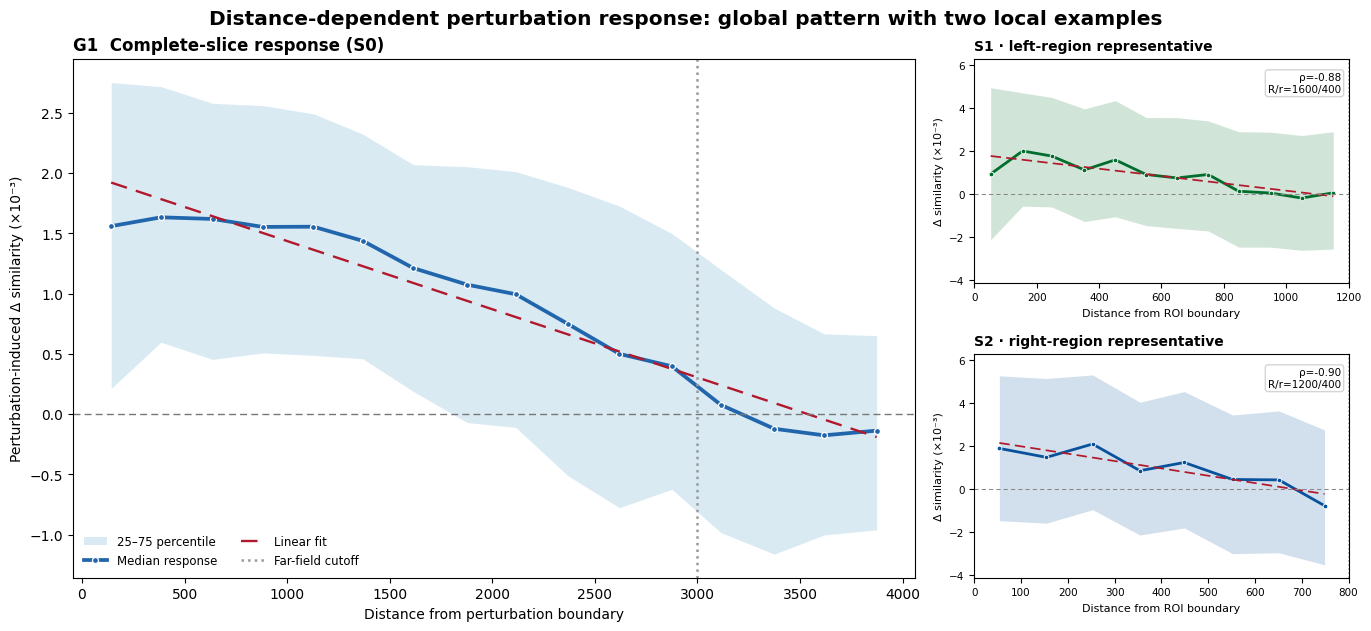

In [12]:
def fit_line(profile):
    x = profile['distance_median'].to_numpy(float)
    y = profile['local_median'].to_numpy(float)
    finite = np.isfinite(x) & np.isfinite(y)
    coef = np.polyfit(x[finite], y[finite], 1)
    return (x[finite], np.polyval(coef, x[finite]))
fig = plt.figure(figsize=(13.6, 6.2), constrained_layout=True)
gs = fig.add_gridspec(2, 2, width_ratios=[2.25, 1.0], height_ratios=[1, 1])
ax_s0 = fig.add_subplot(gs[:, 0])
ax_gt8 = fig.add_subplot(gs[0, 1])
ax_bf16 = fig.add_subplot(gs[1, 1], sharey=ax_gt8)
s0 = profiles['S0']
s0_scale = 1000.0
ax_s0.fill_between(s0['distance_median'], s0['local_q25'] * s0_scale, s0['local_q75'] * s0_scale, color='#A6CEE3', alpha=0.42, linewidth=0, label='25–75 percentile')
ax_s0.plot(s0['distance_median'], s0['local_median'] * s0_scale, color='#2166AC', lw=2.7, marker='o', ms=4.3, markeredgecolor='white', markeredgewidth=0.9, label='Median response')
(x_fit, y_fit) = fit_line(s0)
ax_s0.plot(x_fit, y_fit * s0_scale, color='#B2182B', lw=1.7, ls=(0, (7, 4)), label='Linear fit')
ax_s0.axhline(0, color='#777777', lw=1.0, ls=(0, (5, 3)))
ax_s0.axvline(3000, color='#999999', lw=1.8, ls=':', label='Far-field cutoff')
ax_s0.set_title('G1  Complete-slice response (S0)', loc='left', weight='bold')
ax_s0.set_xlabel('Distance from perturbation boundary')
ax_s0.set_ylabel('Perturbation-induced Δ similarity (×10⁻³)')
ax_s0.legend(frameon=False, fontsize=8.5, loc='lower left', ncol=2)
mini_specs = [(ax_gt8, 'GT8', 'S1 · left-region representative', 1200.0), (ax_bf16, 'BF16', 'S2 · right-region representative', 800.0)]
mini_values = []
for (_, display_id, _, _) in mini_specs:
    p = profiles[display_id]
    mini_values.extend((p['local_q25'] * 1000.0).tolist())
    mini_values.extend((p['local_q75'] * 1000.0).tolist())
mini_values = np.asarray(mini_values, dtype=float)
mini_values = mini_values[np.isfinite(mini_values)]
(y_lo, y_hi) = np.quantile(mini_values, [0.02, 0.98])
y_pad = max((y_hi - y_lo) * 0.12, 0.2)
for (ax, display_id, subtitle, cutoff) in mini_specs:
    p = profiles[display_id]
    row = selected_indexed.loc[display_id]
    ax.fill_between(p['distance_median'], p['local_q25'] * 1000.0, p['local_q75'] * 1000.0, color=COLORS[display_id], alpha=0.18, linewidth=0)
    ax.plot(p['distance_median'], p['local_median'] * 1000.0, color=COLORS[display_id], lw=2.0, marker='o', ms=3.4, markeredgecolor='white', markeredgewidth=0.65)
    (x_fit, y_fit) = fit_line(p)
    ax.plot(x_fit, y_fit * 1000.0, color='#B2182B', lw=1.25, ls=(0, (6, 3)))
    ax.axhline(0, color='#888888', lw=0.75, ls=(0, (4, 3)))
    ax.axvline(cutoff, color='#999999', lw=1.1, ls=':')
    ax.set_xlim(0, cutoff)
    ax.set_ylim(y_lo - y_pad, y_hi + y_pad)
    ax.set_title(subtitle, loc='left', weight='bold', fontsize=10)
    ax.text(0.98, 0.94, f'ρ={row.rho:.2f}\nR/r={row.domain_radius:.0f}/{row.roi_radius:.0f}', transform=ax.transAxes, ha='right', va='top', fontsize=7.5, bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#D0D0D0', alpha=0.88))
    ax.set_xlabel('Distance from ROI boundary', fontsize=8)
    ax.set_ylabel('Δ similarity (×10⁻³)', fontsize=8)
    ax.tick_params(labelsize=7.5)
fig.suptitle('Distance-dependent perturbation response: global pattern with two local examples', fontsize=14.5, weight='bold')
save_panel(fig, 'Fig5_G_PTEN_distance_response')

## H. Completed gene and regulon screens

In [3]:
SI = ROOT / "downstream_tasks/SI_dataset_analysis"
LANDSCAPE_SOURCE = TUTORIAL / 'data/04_glioma'
target_linked_genes = pd.read_csv(LANDSCAPE_SOURCE / "target_linked/target_linked_regulon_gene_table.csv")
three_way_combined = pd.read_csv(LANDSCAPE_SOURCE / "three_way_combined_landscape_table.csv")
REGULON_TABLE = TUTORIAL / 'data/04_glioma/xenium_gbm_regulon_table_ko_all_preview_human_ffpe.csv'
regulon = pd.read_csv(REGULON_TABLE)
combined_regulon = regulon[regulon["collection"].eq("combined")].copy()
TARGET_LINKED_DIR = analysis_dir / "target_linked"
TARGET_LINKED_DIR.mkdir(exist_ok=True)
def display_then_save_target_linked(fig, stem, dpi=300):
    save_panel(fig,"Fig5_H_gene_regulon_landscape")

TL-A: 显示全部 319 个 KO/OE 基因；其中 176 个按 target-linked regulon context 着色，143 个无 target link 的基因显示为浅灰。
标签：10 个达到 |KO|、|OE|>0.001 的 GBM-related 非TF，另加 6 个 KO/OE方向互逆的 direct TF（TF不设0.001门槛）。


,gene_symbol,gene_ko_delta,gene_oe_delta,is_direct_tf_for_label,label_reason,target_linked_regulon_context_score,n_linked_regulons,target_linked_consistency_n,target_linked_ccs
302,STAT3,-0.002859,0.011527,True,Direct TF; reciprocal direction (no magnitude ...,-0.001039,15.0,0,0.000000
278,SOX2,-0.000896,0.003694,True,Direct TF; reciprocal direction (no magnitude ...,NaN,NaN,0,NaN
294,SOX9,-0.001557,0.003474,True,Direct TF; reciprocal direction (no magnitude ...,-0.006797,6.0,0,0.000000
265,SPI1,-0.000559,0.002488,True,Direct TF; reciprocal direction (no magnitude ...,-0.006524,6.0,0,0.000000
77,KLF4,0.000519,-0.000234,True,Direct TF; reciprocal direction (no magnitude ...,-0.000099,6.0,2,0.466638
76,TP53,0.000571,-0.001366,True,Direct TF; reciprocal direction (no magnitude ...,0.000245,28.0,3,0.748940
317,BEX1,-0.030398,0.016040,False,GBM-related non-TF; reciprocal |KO|/|OE| > 0.001,NaN,NaN,0,NaN
303,PTEN,-0.002871,0.015818,False,GBM-related non-TF; reciprocal |KO|/|OE| > 0.001,-0.001613,13.0,0,0.000000
318,NRGN,-0.061594,0.014795,False,GBM-related non-TF; reciprocal |KO|/|OE| > 0.001,NaN,NaN,0,NaN
310,APOE,-0.004019,0.014532,False,GBM-related non-TF; reciprocal |KO|/|OE| > 0.001,-0.005867,3.0,0,0.000000


双向 combined-regulon 3/3 黑圈 TF: TP53, KLF4, SOX2, STAT3


,gene_symbol,gene_ko_delta,gene_oe_delta,regulon_ko_delta,strict_bidirectional_3of3
1,TP53,0.000571,-0.001366,0.008564,True
2,KLF4,0.000519,-0.000234,0.002567,True
4,SOX2,-0.000896,0.003694,-0.005260,True
6,STAT3,-0.002859,0.011527,-0.001627,True


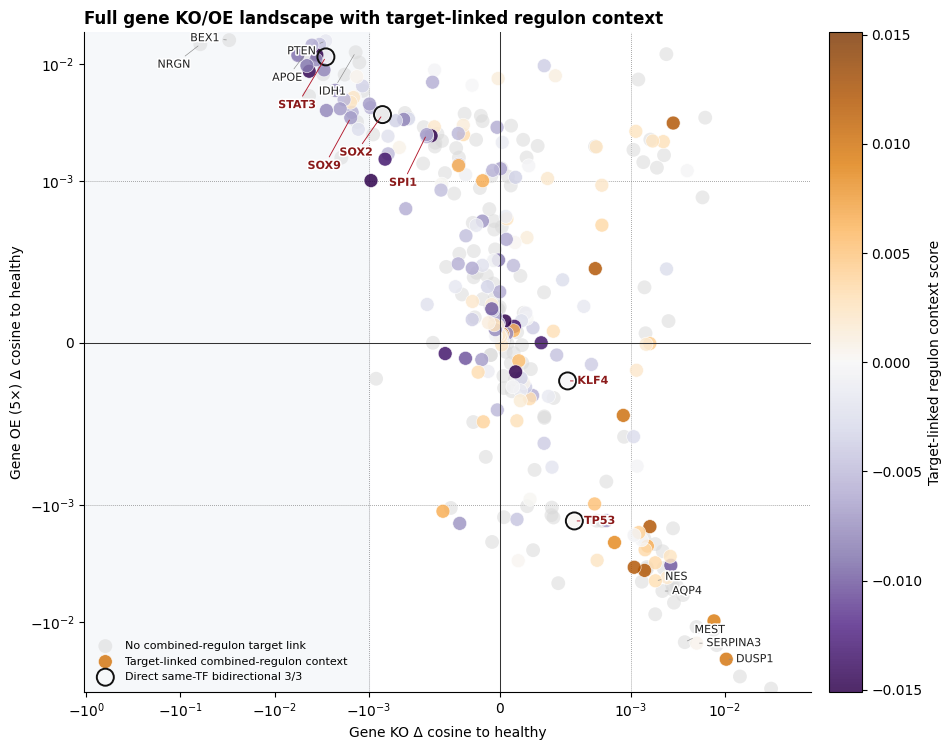

In [4]:
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from matplotlib import patheffects
plot_all = target_linked_genes.copy()
linked_plot = plot_all.loc[plot_all['has_target_linked_context']].copy()
unlinked_plot = plot_all.loc[~plot_all['has_target_linked_context']].copy()
if linked_plot.empty:
    raise ValueError('TL-A requires at least one target-linked gene.')
context_limit = max(float(np.quantile(np.abs(linked_plot['target_linked_regulon_context_score']), 0.98)), 1e-06)
context_norm = TwoSlopeNorm(vmin=-context_limit, vcenter=0, vmax=context_limit)
context_cmap = plt.get_cmap('PuOr_r')
GBM_RELATED_GENES = {'AKT1', 'APOE', 'AQP4', 'ASCL1', 'ATF3', 'ATRX', 'BAX', 'BCL2', 'BEX1', 'BCAN', 'BRAF', 'CCND1', 'CD44', 'CDK4', 'CDK6', 'CDKN1A', 'CDKN2A', 'CDKN2B', 'CHI3L1', 'CSPG4', 'DLL3', 'DUSP1', 'E2F1', 'EGFR', 'ERBB2', 'ERBB3', 'EZH2', 'FGFR3', 'FOS', 'FOXM1', 'GFAP', 'H3F3A', 'HIF1A', 'IDH1', 'IDH2', 'JUN', 'KLF4', 'MDM2', 'MDM4', 'MEST', 'MET', 'MKI67', 'MTOR', 'MYC', 'MYCN', 'NES', 'NF1', 'NFKB1', 'NOTCH1', 'NOTCH2', 'NRGN', 'OLIG1', 'OLIG2', 'PDGFRA', 'PIK3CA', 'PIK3R1', 'PROM1', 'PTEN', 'RB1', 'RELA', 'RUNX1', 'SERPINA3', 'SOX2', 'SOX9', 'SOX10', 'SP1', 'SPI1', 'STAT3', 'STAT6', 'TERT', 'TNC', 'TP53', 'VEGFA', 'VIM', 'WWTR1', 'YAP1'}
DIRECT_TF_SYMBOLS = set(combined_regulon['tf_symbol'].dropna().astype(str))
LABEL_EFFECT_THRESHOLD = 0.001
ko_all = pd.to_numeric(plot_all['gene_ko_delta'], errors='coerce')
oe_all = pd.to_numeric(plot_all['gene_oe_delta'], errors='coerce')
plot_all['is_direct_tf_for_label'] = plot_all['gene_symbol'].astype(str).isin(DIRECT_TF_SYMBOLS)
plot_all['ko_oe_reciprocal_for_label'] = ko_all.notna() & oe_all.notna() & ko_all.ne(0) & oe_all.ne(0) & (ko_all * oe_all < 0)
strong_qii = ko_all.lt(-LABEL_EFFECT_THRESHOLD) & oe_all.gt(LABEL_EFFECT_THRESHOLD)
strong_qiv = ko_all.gt(LABEL_EFFECT_THRESHOLD) & oe_all.lt(-LABEL_EFFECT_THRESHOLD)
strong_reciprocal = strong_qii | strong_qiv
gbm_non_tf_label = plot_all['gene_symbol'].astype(str).isin(GBM_RELATED_GENES) & ~plot_all['is_direct_tf_for_label'] & strong_reciprocal
tf_reciprocal_label = plot_all['is_direct_tf_for_label'] & plot_all['ko_oe_reciprocal_for_label']
plot_all['label_reason'] = ''
plot_all.loc[gbm_non_tf_label, 'label_reason'] = 'GBM-related non-TF; reciprocal |KO|/|OE| > 0.001'
plot_all.loc[tf_reciprocal_label, 'label_reason'] = 'Direct TF; reciprocal direction (no magnitude cutoff)'
label_candidates = plot_all.loc[gbm_non_tf_label | tf_reciprocal_label].copy().sort_values(['is_direct_tf_for_label', 'gene_oe_delta', 'gene_ko_delta'], ascending=[False, False, True]).drop_duplicates('gene_symbol')
print(f'TL-A: 显示全部 {len(plot_all)} 个 KO/OE 基因；其中 {len(linked_plot)} 个按 target-linked regulon context 着色，{len(unlinked_plot)} 个无 target link 的基因显示为浅灰。')
print(f'标签：{int(gbm_non_tf_label.sum())} 个达到 |KO|、|OE|>0.001 的 GBM-related 非TF，另加 {int(tf_reciprocal_label.sum())} 个 KO/OE方向互逆的 direct TF（TF不设0.001门槛）。')
display_columns = ['gene_symbol', 'gene_ko_delta', 'gene_oe_delta', 'is_direct_tf_for_label', 'label_reason', 'target_linked_regulon_context_score', 'n_linked_regulons', 'target_linked_consistency_n', 'target_linked_ccs']
display(label_candidates[display_columns])
label_candidates[display_columns].to_csv(TARGET_LINKED_DIR / 'TL_A_labelled_GBM_reciprocal_genes.csv', index=False)
(fig, ax) = plt.subplots(figsize=(9.8, 7.6))
ax.scatter(unlinked_plot['gene_ko_delta'], unlinked_plot['gene_oe_delta'], s=100, color='#D8D8D8', alpha=0.52, edgecolor='none', label='No combined-regulon target link', zorder=1)
point_sizes = 100
scatter = ax.scatter(linked_plot['gene_ko_delta'], linked_plot['gene_oe_delta'], c=linked_plot['target_linked_regulon_context_score'], cmap=context_cmap, norm=context_norm, s=point_sizes, alpha=0.84, edgecolor='white', linewidth=0.45, label='Target-linked combined-regulon context', zorder=2)
strict_direct_audit = three_way_combined.copy()
strict_direct_audit['ko_oe_reciprocal'] = strict_direct_audit['gene_ko_delta'] * strict_direct_audit['gene_oe_delta'] < 0
strict_direct_audit['regulon_matches_ko'] = strict_direct_audit['gene_ko_delta'] * strict_direct_audit['regulon_ko_delta'] > 0
strict_direct_audit['strict_bidirectional_3of3'] = strict_direct_audit['ko_oe_reciprocal'] & strict_direct_audit['regulon_matches_ko']
strict_direct = strict_direct_audit.loc[strict_direct_audit['strict_bidirectional_3of3']].copy()
strict_direct.to_csv(TARGET_LINKED_DIR / 'TL_A_direct_TF_bidirectional_3of3.csv', index=False)
print('双向 combined-regulon 3/3 黑圈 TF:', ', '.join(strict_direct['gene_symbol'].astype(str)))
display(strict_direct[['gene_symbol', 'gene_ko_delta', 'gene_oe_delta', 'regulon_ko_delta', 'strict_bidirectional_3of3']])
ax.scatter(strict_direct['gene_ko_delta'], strict_direct['gene_oe_delta'], s=150, facecolor='none', edgecolor='#111111', linewidth=1.4, label='Direct same-TF bidirectional 3/3', zorder=6)
ax.axvspan(-1, -LABEL_EFFECT_THRESHOLD, ymin=0, ymax=1, color='#F5F7FA', alpha=0.86, zorder=0)
ax.axvline(0, color='#333333', lw=0.75)
ax.axhline(0, color='#333333', lw=0.75)
ax.axvline(-LABEL_EFFECT_THRESHOLD, color='#777777', lw=0.55, ls=':', zorder=0)
ax.axvline(LABEL_EFFECT_THRESHOLD, color='#777777', lw=0.55, ls=':', zorder=0)
ax.axhline(-LABEL_EFFECT_THRESHOLD, color='#777777', lw=0.55, ls=':', zorder=0)
ax.axhline(LABEL_EFFECT_THRESHOLD, color='#777777', lw=0.55, ls=':', zorder=0)
ax.set_xscale('symlog', linthresh=0.001, linscale=1.25)
ax.set_yscale('symlog', linthresh=0.001, linscale=1.25)
ax.set_xlabel('Gene KO Δ cosine to healthy')
ax.set_ylabel('Gene OE (5×) Δ cosine to healthy')
ax.set_title('Full gene KO/OE landscape with target-linked regulon context', loc='left', fontweight='bold')
fig.canvas.draw()
axes_bbox = ax.get_window_extent()
min_gap_px = 13.0
label_layout = []
for (side_name, side_frame) in label_candidates.groupby(np.where(label_candidates['gene_ko_delta'].to_numpy() >= 0, 'right', 'left')):
    side_rows = list(side_frame.itertuples())
    anchor_y = np.array([ax.transData.transform((row.gene_ko_delta, row.gene_oe_delta))[1] for row in side_rows])
    order = np.argsort(anchor_y)
    target_y = anchor_y[order].copy()
    for idx in range(1, len(target_y)):
        target_y[idx] = max(target_y[idx], target_y[idx - 1] + min_gap_px)
    upper = axes_bbox.y1 - 5
    lower = axes_bbox.y0 + 5
    if len(target_y) and target_y[-1] > upper:
        target_y -= target_y[-1] - upper
    for idx in range(len(target_y) - 2, -1, -1):
        target_y[idx] = min(target_y[idx], target_y[idx + 1] - min_gap_px)
    if len(target_y) and target_y[0] < lower:
        target_y += lower - target_y[0]
    for (sorted_idx, original_idx) in enumerate(order):
        row = side_rows[original_idx]
        dy_points = (target_y[sorted_idx] - anchor_y[original_idx]) * 72.0 / fig.dpi
        label_layout.append((side_name, row, dy_points))
for (side_name, row, dy_points) in label_layout:
    is_tf = bool(row.is_direct_tf_for_label)
    x_offset = 7 if side_name == 'right' else -7
    text = ax.annotate(row.gene_symbol, (row.gene_ko_delta, row.gene_oe_delta), xytext=(x_offset, dy_points), textcoords='offset points', ha='left' if side_name == 'right' else 'right', va='center', fontsize=8.0, fontweight='bold' if is_tf else 'normal', color='#8B1A1A' if is_tf else '#222222', arrowprops={'arrowstyle': '-', 'color': '#B2182B' if is_tf else '#888888', 'linewidth': 0.65 if is_tf else 0.45, 'shrinkA': 1, 'shrinkB': 2}, annotation_clip=False, zorder=10)
    text.set_path_effects([patheffects.withStroke(linewidth=2.2, foreground='white')])
colorbar = fig.colorbar(scatter, ax=ax, pad=0.02)
colorbar.set_label('Target-linked regulon context score')
ax.legend(frameon=False, fontsize=8, loc='lower left')
sns.despine(ax=ax)
fig.tight_layout()
display_then_save_target_linked(fig, 'TL_A_all_319_gene_ko_oe_target_linked_context')